# 4. Market Basket Analysis

## Setup

In [4]:
import time
import warnings

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder
from IPython.display import display, HTML

# Suppress deprecation warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

# Display settings
pd.options.display.float_format = '{:20.4f}'.format
pd.set_option('display.max_columns', None)

c:\Users\Student\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\Student\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [5]:
# Setting a format for the visualization plots 

# setting theme
sns.set_theme(
    style='white',
    font='sans-serif',
    rc={
        'axes.spines.top':    False,
        'axes.spines.right':  False,
        'axes.grid':          True,
        'grid.color':         '#F1EFE8',
        'grid.linewidth':     0.8,
        'axes.facecolor':     'white',
        'axes.titleweight': 'bold',
        'figure.facecolor':   'white',
        'axes.labelcolor':    '#444441',
        'xtick.color':        '#444441',
        'ytick.color':        '#444441',
        'axes.titlesize':     13,
        'axes.labelsize':     11,
        'xtick.labelsize':    10,
        'ytick.labelsize':    10,
        'figure.titlesize':   14,
    }
)

# setting colors
color_assign_mba = {
    'New':          '#5C74B8',
    'Occasional':   '#7A5CB8',
    'Inactive':     '#3DA898',
    'Lost':         '#C95555',
    'Champions':    '#D4853A',
    'VIP':          '#B84E6E',
    'Full Dataset': '#808080'
}

## Data Preparation

#### **Loading data**

In [6]:
# Loading df
df = pd.read_csv('../datasets/03_customer_segments.csv')

#### **Cluster datasets**

In [7]:
# Creating dataset for each customer segment

# Occasional Customers
occasional_df = df[df['Cluster_Label'] == 'Occasional']

# Champions Customers
champions_df = df[df['Cluster_Label'] == 'Champions']

# VIP Customers Customers
vip_df = df[df['Cluster_Label'] == 'VIP']

# Inactive Customers Customers
inactive_df = df[df['Cluster_Label'] == 'Inactive']

# New Customers Customers
new_df = df[df['Cluster_Label'] == 'New']

# Lost Customers  Customers
lost_df = df[df['Cluster_Label'] == 'Lost']


## Feature Engineering

#### **Product list by dataset**

Each order `InvoiceNo` is turned into a basket — a list of all products bought 
together in that transaction. This is the format Apriori and FP-Growth expect: 
one list of items per transaction, not one row per line item.    

This step is repeated for the full dataset and for each customer segment, so 
association rules can be generated and compared at both levels.

##### Full dataset

In [8]:
# Creating a list of products purchased in each transaction
transactions = df.groupby('InvoiceNo')['Description'].apply(list).values.tolist()

# Number of transaction baskets
print(len(transactions))

18358


##### Occasional

In [9]:
# Creating a list of products purchased in each transaction
occasional_list = occasional_df.groupby('InvoiceNo')['Description'].apply(list).values.tolist()

# Number of transaction baskets
print(len(occasional_list))

7259


##### Champions

In [10]:
# Creating a list of products purchased in each transaction
champions_list = champions_df.groupby('InvoiceNo')['Description'].apply(list).values.tolist()

# Number of transaction baskets
print(len(champions_list))

5333


##### VIP

In [11]:
# Creating a list of products purchased in each transaction
vip_list = vip_df.groupby('InvoiceNo')['Description'].apply(list).values.tolist()

# Number of transaction baskets
print(len(vip_list))

2749


##### Inactive

In [12]:
# Creating a list of products purchased in each transaction
inactive_list = inactive_df.groupby('InvoiceNo')['Description'].apply(list).values.tolist()

# Number of transaction baskets
print(len(inactive_list))

1570


##### New

In [13]:
# Creating a list of products purchased in each transaction
new_list = new_df.groupby('InvoiceNo')['Description'].apply(list).values.tolist()

# Number of transaction baskets
print(len(new_list))

659


##### Lost

In [14]:
# Creating a list of products purchased in each transaction
lost_list = lost_df.groupby('InvoiceNo')['Description'].apply(list).values.tolist()

# Number of transaction baskets
print(len(lost_list))

788


#### **Binary transaction by dataset**

`TransactionEncoder` converts the basket lists into a one-hot encoded matrix — 
one row per order, one column per unique product, `True`/`False` for whether 
that product was in the order. This is the format `apriori` and `fpgrowth` 
require as input.

Same as feature engineering, this is applied separately to the full dataset 
and each segment.

**Reference**
- Apriori Implementation: https://rasbt.github.io/mlxtend/user_guide/frequent_patterns/apriori/

##### Full dataset

In [15]:
# Transform transactions into binary matrix
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)

df_encoded = pd.DataFrame(te_array, columns=te.columns_)

print("Matrix")
print("="*50)
print("Unique orders:", df_encoded.shape[0])
print("Unique products:", df_encoded.shape[1])

df_encoded

Matrix
Unique orders: 18358
Unique products: 3845


10 COLOUR SPACEBOY PEN  12 COLOURED PARTY BALLOONS  \
0                       False                       False   
1                       False                       False   
2                       False                       False   
3                       False                       False   
4                       False                       False   
...                       ...                         ...   
18353                   False                       False   
18354                   False                       False   
18355                   False                       False   
18356                   False                       False   
18357                   False                       False   

       12 DAISY PEGS IN WOOD BOX  12 EGG HOUSE PAINTED WOOD  \
0                          False                      False   
1                          False                      False   
2                          False                      False   
3                          False                      False   
4                          False                      False   
...                          ...                        ...   
18353                      False                      False   
18354                      False                      False   
18355                      False                      False   
18356                      False                      False   
18357                      False                      False   

       12 HANGING EGGS HAND PAINTED  12 IVORY ROSE PEG PLACE SETTINGS  \
0                             False                             False   
1                             False                             False   
2                             False                             False   
3                             False                             False   
4                             False                             False   
...                             ...                               ...   
18353                         False                             False   
18354                         False                             False   
18355                         False                             False   
18356                         False                             False   
18357                         False                             False   

       12 MESSAGE CARDS WITH ENVELOPES  12 PENCIL SMALL TUBE WOODLAND  \
0                                False                          False   
1                                False                          False   
2                                False                          False   
3                                False                          False   
4                                False                          False   
...                                ...                            ...   
18353                            False                          False   
18354                            False                          False   
18355                            False                          False   
18356                            False                          False   
18357                            False                          False   

       12 PENCILS SMALL TUBE RED RETROSPOT  12 PENCILS SMALL TUBE SKULL  \
0                                    False                        False   
1                                    False                        False   
2                                    False                        False   
3                                    False                        False   
4                                    False                        False   
...                                    ...                          ...   
18353                                False                        False   
18354                                False                        False   
18355                                False                        False   
18356        

##### Occasional

In [16]:
# Transform transactions into binary matrix
te_occ = TransactionEncoder()
te_array_occ = te_occ.fit(occasional_list).transform(occasional_list)

df_encoded_occ = pd.DataFrame(te_array_occ, columns=te_occ.columns_)

print("Matrix")
print("="*50)
print("Unique orders:", df_encoded_occ.shape[0])
print("Unique products:", df_encoded_occ.shape[1])

df_encoded_occ

Matrix
Unique orders: 7259
Unique products: 3540


10 COLOUR SPACEBOY PEN  12 COLOURED PARTY BALLOONS  \
0                      False                       False   
1                      False                       False   
2                      False                       False   
3                      False                       False   
4                      False                       False   
...                      ...                         ...   
7254                   False                       False   
7255                   False                       False   
7256                   False                       False   
7257                   False                       False   
7258                   False                       False   

      12 DAISY PEGS IN WOOD BOX  12 EGG HOUSE PAINTED WOOD  \
0                         False                      False   
1                         False                      False   
2                         False                      False   
3                         False                      False   
4                         False                      False   
...                         ...                        ...   
7254                      False                      False   
7255                      False                      False   
7256                      False                      False   
7257                      False                      False   
7258                      False                      False   

      12 HANGING EGGS HAND PAINTED  12 IVORY ROSE PEG PLACE SETTINGS  \
0                            False                             False   
1                            False                             False   
2                            False                             False   
3                            False                             False   
4                            False                             False   
...                            ...                               ...   
7254                         False                             False   
7255                         False                             False   
7256                         False                             False   
7257                         False                             False   
7258                         False                             False   

      12 MESSAGE CARDS WITH ENVELOPES  12 PENCIL SMALL TUBE WOODLAND  \
0                               False                          False   
1                               False                          False   
2                               False                          False   
3                               False                          False   
4                               False                          False   
...                               ...                            ...   
7254                            False                          False   
7255                            False                          False   
7256                            False                          False   
7257                            False                          False   
7258                            False                          False   

      12 PENCILS SMALL TUBE RED RETROSPOT  12 PENCILS SMALL TUBE SKULL  \
0                                   False                        False   
1                                   False                        False   
2                                   False                        False   
3                                   False                        False   
4                                   False                        False   
...                                   ...                          ...   
7254                                False                        False   
7255                                False                        False   
7256                                False                        False   
7257                                False                        False

##### Champions

In [17]:
# Transform transactions into binary matrix
te_champ = TransactionEncoder()
te_array_champ = te_champ.fit(champions_list).transform(champions_list)

df_encoded_champ = pd.DataFrame(te_array_champ, columns=te_champ.columns_)

print("Matrix")
print("="*50)
print("Unique orders:", df_encoded_champ.shape[0])
print("Unique products:", df_encoded_champ.shape[1])

df_encoded_champ

Matrix
Unique orders: 5333
Unique products: 3358


10 COLOUR SPACEBOY PEN  12 COLOURED PARTY BALLOONS  \
0                      False                       False   
1                      False                       False   
2                      False                       False   
3                      False                       False   
4                      False                       False   
...                      ...                         ...   
5328                   False                       False   
5329                   False                       False   
5330                   False                       False   
5331                   False                       False   
5332                   False                       False   

      12 DAISY PEGS IN WOOD BOX  12 EGG HOUSE PAINTED WOOD  \
0                         False                      False   
1                         False                      False   
2                         False                      False   
3                         False                      False   
4                         False                      False   
...                         ...                        ...   
5328                      False                      False   
5329                      False                      False   
5330                      False                      False   
5331                      False                      False   
5332                      False                      False   

      12 HANGING EGGS HAND PAINTED  12 IVORY ROSE PEG PLACE SETTINGS  \
0                            False                             False   
1                            False                             False   
2                            False                             False   
3                            False                             False   
4                            False                             False   
...                            ...                               ...   
5328                         False                             False   
5329                         False                             False   
5330                         False                             False   
5331                         False                             False   
5332                         False                             False   

      12 MESSAGE CARDS WITH ENVELOPES  12 PENCIL SMALL TUBE WOODLAND  \
0                               False                          False   
1                               False                          False   
2                               False                          False   
3                               False                          False   
4                               False                          False   
...                               ...                            ...   
5328                            False                          False   
5329                            False                          False   
5330                            False                          False   
5331                            False                          False   
5332                            False                          False   

      12 PENCILS SMALL TUBE RED RETROSPOT  12 PENCILS SMALL TUBE SKULL  \
0                                   False                        False   
1                                   False                        False   
2                                   False                        False   
3                                   False                        False   
4                                   False                        False   
...                                   ...                          ...   
5328                                False                        False   
5329                                False                        False   
5330                                False                        False   
5331                                False                        False

##### VIP

In [18]:
# Transform transactions into binary matrix
te_vip = TransactionEncoder()
te_array_vip = te_vip.fit(vip_list).transform(vip_list)

df_encoded_vip = pd.DataFrame(te_array_vip, columns=te_vip.columns_)

print("Matrix")
print("="*50)
print("Unique orders:", df_encoded_vip.shape[0])
print("Unique products:", df_encoded_vip.shape[1])

df_encoded_vip

Matrix
Unique orders: 2749
Unique products: 3201


10 COLOUR SPACEBOY PEN  12 COLOURED PARTY BALLOONS  \
0                      False                       False   
1                      False                       False   
2                      False                       False   
3                      False                       False   
4                      False                       False   
...                      ...                         ...   
2744                   False                       False   
2745                   False                       False   
2746                   False                       False   
2747                   False                       False   
2748                   False                       False   

      12 DAISY PEGS IN WOOD BOX  12 EGG HOUSE PAINTED WOOD  \
0                         False                      False   
1                         False                      False   
2                         False                      False   
3                         False                      False   
4                         False                      False   
...                         ...                        ...   
2744                      False                      False   
2745                      False                      False   
2746                      False                      False   
2747                      False                      False   
2748                      False                      False   

      12 IVORY ROSE PEG PLACE SETTINGS  12 MESSAGE CARDS WITH ENVELOPES  \
0                                False                            False   
1                                False                            False   
2                                False                            False   
3                                False                            False   
4                                False                            False   
...                                ...                              ...   
2744                             False                            False   
2745                             False                            False   
2746                             False                             True   
2747                             False                            False   
2748                             False                            False   

      12 PENCIL SMALL TUBE WOODLAND  12 PENCILS SMALL TUBE RED RETROSPOT  \
0                             False                                False   
1                             False                                False   
2                             False                                False   
3                             False                                False   
4                             False                                False   
...                             ...                                  ...   
2744                          False                                False   
2745                          False                                False   
2746                          False                                False   
2747                          False                                False   
2748                          False                                False   

      12 PENCILS SMALL TUBE SKULL  12 PENCILS TALL TUBE POSY  \
0                           False                      False   
1                           False                      False   
2                           False                      False   
3                           False                      False   
4                           False                      False   
...                           ...                        ...   
2744                        False                      False   
2745                        False                      False   
2746                         True                      False   
2747                        False                      False   
2748                  

##### Inactive

In [19]:
# Transform transactions into binary matrix
te_inac = TransactionEncoder()
te_array_inac = te_inac.fit(inactive_list).transform(inactive_list)

df_encoded_inac = pd.DataFrame(te_array_inac, columns=te_inac.columns_)

print("Matrix")
print("="*50)
print("Unique orders:", df_encoded_inac.shape[0])
print("Unique products:", df_encoded_inac.shape[1])

df_encoded_inac

Matrix
Unique orders: 1570
Unique products: 2852


10 COLOUR SPACEBOY PEN  12 COLOURED PARTY BALLOONS  \
0                      False                       False   
1                      False                       False   
2                      False                       False   
3                      False                       False   
4                      False                       False   
...                      ...                         ...   
1565                   False                       False   
1566                   False                       False   
1567                   False                       False   
1568                   False                       False   
1569                   False                       False   

      12 DAISY PEGS IN WOOD BOX  12 EGG HOUSE PAINTED WOOD  \
0                         False                      False   
1                         False                      False   
2                         False                      False   
3                         False                      False   
4                         False                      False   
...                         ...                        ...   
1565                      False                      False   
1566                      False                      False   
1567                      False                      False   
1568                      False                      False   
1569                      False                      False   

      12 IVORY ROSE PEG PLACE SETTINGS  12 MESSAGE CARDS WITH ENVELOPES  \
0                                False                            False   
1                                False                            False   
2                                False                            False   
3                                False                            False   
4                                False                            False   
...                                ...                              ...   
1565                             False                            False   
1566                             False                            False   
1567                             False                            False   
1568                             False                            False   
1569                             False                            False   

      12 PENCIL SMALL TUBE WOODLAND  12 PENCILS SMALL TUBE RED RETROSPOT  \
0                             False                                False   
1                             False                                False   
2                             False                                False   
3                             False                                False   
4                             False                                False   
...                             ...                                  ...   
1565                          False                                False   
1566                          False                                False   
1567                          False                                False   
1568                          False                                False   
1569                          False                                False   

      12 PENCILS SMALL TUBE SKULL  12 PENCILS TALL TUBE POSY  \
0                           False                      False   
1                           False                      False   
2                           False                      False   
3                           False                      False   
4                           False                      False   
...                           ...                        ...   
1565                        False                      False   
1566                        False                      False   
1567                        False                      False   
1568                        False                      False   
1569                  

##### New

In [20]:
# Transform transactions into binary matrix
te_new = TransactionEncoder()
te_array_new = te_new.fit(new_list).transform(new_list)

df_encoded_new = pd.DataFrame(te_array_new, columns=te_new.columns_)

print("Matrix")
print("="*50)
print("Unique orders:", df_encoded_new.shape[0])
print("Unique products:", df_encoded_new.shape[1])

df_encoded_new

Matrix
Unique orders: 659
Unique products: 2419


10 COLOUR SPACEBOY PEN  12 COLOURED PARTY BALLOONS  \
0                     False                       False   
1                     False                       False   
2                     False                       False   
3                     False                       False   
4                     False                       False   
..                      ...                         ...   
654                   False                       False   
655                   False                       False   
656                   False                       False   
657                   False                       False   
658                   False                       False   

     12 EGG HOUSE PAINTED WOOD  12 HANGING EGGS HAND PAINTED  \
0                        False                         False   
1                        False                         False   
2                        False                         False   
3                        False                         False   
4                        False                         False   
..                         ...                           ...   
654                      False                         False   
655                      False                         False   
656                      False                         False   
657                      False                         False   
658                      False                         False   

     12 MESSAGE CARDS WITH ENVELOPES  12 PENCIL SMALL TUBE WOODLAND  \
0                              False                          False   
1                              False                          False   
2                              False                          False   
3                              False                          False   
4                               True                          False   
..                               ...                            ...   
654                            False                          False   
655                            False                          False   
656                            False                          False   
657                            False                          False   
658                            False                          False   

     12 PENCILS SMALL TUBE RED RETROSPOT  12 PENCILS SMALL TUBE SKULL  \
0                                  False                        False   
1                                  False                        False   
2                                  False                        False   
3                                  False                        False   
4                                  False                        False   
..                                   ...                          ...   
654                                False                        False   
655                                False                        False   
656                                False                        False   
657                                False                        False   
658                                False                        False   

     12 PENCILS TALL TUBE POSY  12 PENCILS TALL TUBE RED RETROSPOT  \
0                        False                               False   
1                        False                               False   
2                        False                               False   
3                        False                               False   
4                        False                               False   
..                         ...                                 ...   
654                      False                               False   
655                      False                               False   
656                      False                               False   
657                      False                               False   
658                      Fa

##### Lost

In [21]:
# Transform transactions into binary matrix
te_lost = TransactionEncoder()
te_array_lost = te_lost.fit(lost_list).transform(lost_list)

df_encoded_lost = pd.DataFrame(te_array_lost, columns=te_lost.columns_)

print("Matrix")
print("="*50)
print("Unique orders:", df_encoded_lost.shape[0])
print("Unique products:", df_encoded_lost.shape[1])

df_encoded_lost

Matrix
Unique orders: 788
Unique products: 2273


10 COLOUR SPACEBOY PEN  12 COLOURED PARTY BALLOONS  \
0                     False                       False   
1                     False                       False   
2                     False                       False   
3                     False                       False   
4                     False                       False   
..                      ...                         ...   
783                   False                       False   
784                   False                       False   
785                   False                       False   
786                   False                       False   
787                   False                       False   

     12 DAISY PEGS IN WOOD BOX  12 EGG HOUSE PAINTED WOOD  \
0                        False                      False   
1                        False                      False   
2                        False                      False   
3                        False                      False   
4                        False                      False   
..                         ...                        ...   
783                      False                      False   
784                      False                      False   
785                      False                      False   
786                      False                      False   
787                      False                      False   

     12 IVORY ROSE PEG PLACE SETTINGS  12 MESSAGE CARDS WITH ENVELOPES  \
0                               False                            False   
1                               False                            False   
2                               False                            False   
3                               False                            False   
4                               False                            False   
..                                ...                              ...   
783                             False                            False   
784                             False                            False   
785                             False                            False   
786                             False                            False   
787                             False                            False   

     12 PENCIL SMALL TUBE WOODLAND  12 PENCILS SMALL TUBE RED RETROSPOT  \
0                            False                                False   
1                            False                                False   
2                            False                                False   
3                            False                                False   
4                            False                                False   
..                             ...                                  ...   
783                          False                                False   
784                          False                                False   
785                          False                                False   
786                          False                                False   
787                          False                                False   

     12 PENCILS SMALL TUBE SKULL  12 PENCILS TALL TUBE POSY  \
0                          False                      False   
1                          False                      False   
2                          False                      False   
3                          False                      False   
4                          False                      False   
..                           ...                        ...   
783                        False                      False   
784                        False                      False   
785                        False                      False   
786                        False                      False   
787                        False                      False   

     12 PENCILS 

#### **Exploratory Overview**

In [22]:
# Dataset Overview
print(f"Unique customers: {df['CustomerID'].nunique():,}")
print(f"Unique products: {df['Description'].nunique():,}")
print(f"Unique invoices/orders: {df['InvoiceNo'].nunique():,}")

Unique customers: 4,331
Unique products: 3,845
Unique invoices/orders: 18,358


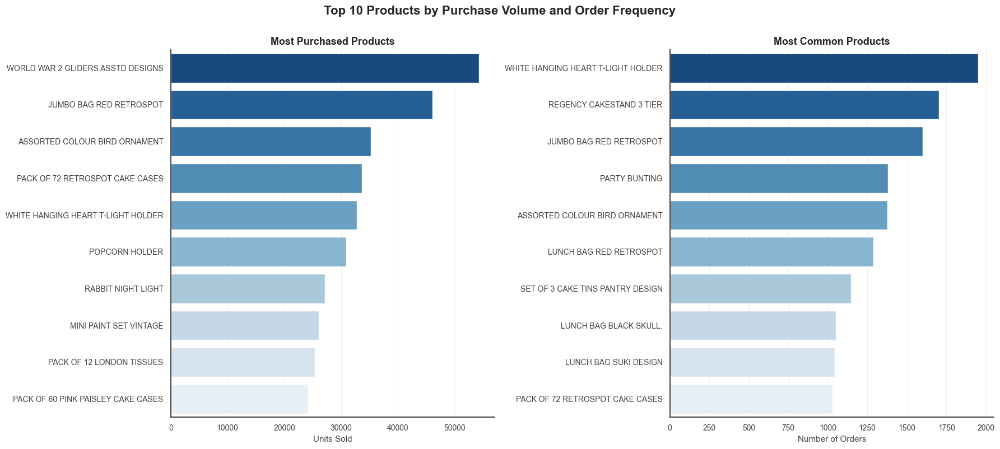

In [23]:
# Calculating product purchase frequency
product_units = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False)
product_orders = df.groupby('Description')['InvoiceNo'].nunique().sort_values(ascending=False)


# Selecting top 10 products
top_units = product_units.head(10)
top_orders = product_orders.head(10)

# Setting figures
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Most purchased products
sns.barplot(
    y=top_units.index,
    x=top_units.values,
    hue=top_units.index,
    palette='Blues_r',
    legend=False,
    ax=ax1
)

ax1.set_title('Most Purchased Products')
ax1.set_xlabel('Units Sold')
ax1.set_ylabel('')

# Most common products
sns.barplot(
    y=top_orders.index,
    x=top_orders.values,
    hue=top_orders.index,
    palette='Blues_r',
    legend=False,
    ax=ax2
)

ax2.set_title('Most Common Products')
ax2.set_xlabel('Number of Orders')
ax2.set_ylabel('')

plt.suptitle(
    'Top 10 Products by Purchase Volume and Order Frequency',
    fontsize=16,
    fontweight='bold',
    y=1
)

plt.tight_layout()
plt.show()

## Association Rule Mining

Both algorithms are applied to the same encoded matrix, using a minimum support 
of 0.01 (itemset must appear in at least 1% of transactions). Apriori and FP-Growth 
are compared here to evaluate the best method.    

Association rules are generated from the Apriori itemsets, filtered on a 
minimum confidence of 0.60, and sorted by lift.

Itemset size breakdown shows how many 1-item, 2-item, 3-item (etc.) 
combinations were found — single items don't produce rules on their own, 
but show which products are individually most common.


**References**    
- Youtube tutorial Association Rule Mining: https://www.youtube.com/watch?v=WIlLZnYUzcw&list=LL&index=15&t=308s      
- mlxtend Apriori: https://rasbt.github.io/mlxtend/user_guide/frequent_patterns/apriori/      
- mlxtend Association Rules: https://rasbt.github.io/mlxtend/user_guide/frequent_patterns/association_rules/      
- mlxtend FP-Growth: https://rasbt.github.io/mlxtend/user_guide/frequent_patterns/fpgrowth/       

#### Full dataset

**Apriori, FP-Growth, Association Rules**

In [24]:
# 1. Frequent itemsets
frequent_itemsets = apriori(df_encoded, min_support=0.01, use_colnames=True)
frequent_itemsets_fp = fpgrowth(df_encoded, min_support=0.01, use_colnames=True)

# 2. Association rules
df_rules = association_rules(frequent_itemsets, metric='confidence', min_threshold = 0.6)
rules = df_rules[['antecedents','consequents','antecedent support','consequent support','support','confidence','lift']].sort_values('lift', ascending=False)

# 3. show breakdown by itemset size
itemset_size_count = frequent_itemsets['itemsets'].apply(len).value_counts().sort_index()
itemset_size_count_fp = frequent_itemsets_fp['itemsets'].apply(len).value_counts().sort_index()


**Running time difference**

In [25]:
# Checking running time 
start = time.time()
apriori(df_encoded, min_support=0.01, use_colnames=True)
print(f"Apriori: {time.time() - start:.4f}s")

start = time.time()
fpgrowth(df_encoded, min_support=0.01, use_colnames=True)
print(f"FP-Growth: {time.time() - start:.4f}s")

Apriori: 5.3234s
FP-Growth: 1.8377s


**Algorithm results**

In [26]:
# Apriori results
print("APRIORI")
print("="*50)
print("Total itemsets found:", len(frequent_itemsets))
print("="*50)
print(itemset_size_count)
print("="*50)
frequent_itemsets.sort_values('support', ascending=False).head(10)

APRIORI
Total itemsets found: 997
itemsets
1    623
2    309
3     62
4      3
Name: count, dtype: int64


,support,itemsets
590,0.1063,frozenset({WHITE HANGING HEART T-LIGHT HOLDER})
414,0.0928,frozenset({REGENCY CAKESTAND 3 TIER})
248,0.0872,frozenset({JUMBO BAG RED RETROSPOT})
338,0.0751,frozenset({PARTY BUNTING})
37,0.0749,frozenset({ASSORTED COLOUR BIRD ORNAMENT})
283,0.0702,frozenset({LUNCH BAG RED RETROSPOT})
469,0.0624,frozenset({SET OF 3 CAKE TINS PANTRY DESIGN})
277,0.0573,frozenset({LUNCH BAG BLACK SKULL.})
285,0.0568,frozenset({LUNCH BAG SUKI DESIGN})
323,0.0561,frozenset({PACK OF 72 RETROSPOT CAKE CASES})


Total frequent itemsets found, broken down by size, followed by the top 10 
itemsets by support — the products (or product combinations) that appear 
most often across all transactions in this segment.

In [27]:
# FP-Growth results
print("FP-GROWTH")
print("="*50)
print("Total itemsets found:", len(frequent_itemsets_fp))
print("="*50)
print(itemset_size_count_fp)
print("="*50)
frequent_itemsets_fp.sort_values('support', ascending=False).head(10)

FP-GROWTH
Total itemsets found: 997
itemsets
1    623
2    309
3     62
4      3
Name: count, dtype: int64


,support,itemsets
86,0.1063,frozenset({WHITE HANGING HEART T-LIGHT HOLDER})
248,0.0928,frozenset({REGENCY CAKESTAND 3 TIER})
74,0.0872,frozenset({JUMBO BAG RED RETROSPOT})
439,0.0751,frozenset({PARTY BUNTING})
0,0.0749,frozenset({ASSORTED COLOUR BIRD ORNAMENT})
27,0.0702,frozenset({LUNCH BAG RED RETROSPOT})
468,0.0624,frozenset({SET OF 3 CAKE TINS PANTRY DESIGN})
149,0.0573,frozenset({LUNCH BAG BLACK SKULL.})
150,0.0568,frozenset({LUNCH BAG SUKI DESIGN})
28,0.0561,frozenset({PACK OF 72 RETROSPOT CAKE CASES})


**Association rules**

In [28]:
# Association Rules
display(HTML(rules.head(5).to_html()))
display(HTML(rules.tail(5).to_html()))

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift
145,"frozenset({REGENCY TEA PLATE ROSES, REGENCY TEA PLATE GREEN})",frozenset({REGENCY TEA PLATE PINK}),0.0125,0.0122,0.0101,0.8079,66.2085
146,frozenset({REGENCY TEA PLATE PINK}),"frozenset({REGENCY TEA PLATE ROSES, REGENCY TEA PLATE GREEN})",0.0122,0.0125,0.0101,0.8259,66.2085
143,"frozenset({REGENCY TEA PLATE PINK, REGENCY TEA PLATE ROSES})",frozenset({REGENCY TEA PLATE GREEN}),0.0107,0.0147,0.0101,0.9391,63.8509
147,frozenset({REGENCY TEA PLATE GREEN}),"frozenset({REGENCY TEA PLATE PINK, REGENCY TEA PLATE ROSES})",0.0147,0.0107,0.0101,0.6852,63.8509
54,frozenset({REGENCY TEA PLATE GREEN}),frozenset({REGENCY TEA PLATE PINK}),0.0147,0.0122,0.0110,0.7481,61.3147


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift
35,frozenset({JUMBO BAG PINK POLKADOT}),frozenset({JUMBO BAG RED RETROSPOT}),0.0474,0.0872,0.0297,0.6269,7.1925
15,frozenset({CANDLEHOLDER PINK HANGING HEART}),frozenset({WHITE HANGING HEART T-LIGHT HOLDER}),0.0187,0.1063,0.0138,0.7376,6.9370
150,"frozenset({PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY TEACUP AND SAUCER, GREEN REGENCY TEACUP AND SAUCER})",frozenset({REGENCY CAKESTAND 3 TIER}),0.0212,0.0928,0.0130,0.6128,6.6061
138,"frozenset({PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY TEACUP AND SAUCER})",frozenset({REGENCY CAKESTAND 3 TIER}),0.0237,0.0928,0.0144,0.6078,6.5519
47,frozenset({RED HANGING HEART T-LIGHT HOLDER}),frozenset({WHITE HANGING HEART T-LIGHT HOLDER}),0.0370,0.1063,0.0248,0.6701,6.3021


**Metrics**

In [77]:
print(f"Total rules: {len(rules):,}")
print(f"Average support: {rules['support'].mean():.4f}")
print(f"Average confidence: {rules['confidence'].mean():.4f}")
print(f"Average lift: {rules['lift'].mean():.4f}")
print("Total transactions", df['InvoiceNo'].nunique())
print("Total products", df['Description'].nunique())

Total rules: 162
Average support: 0.0139
Average confidence: 0.6990
Average lift: 22.8231
Total transactions 18358
Total products 3845


#### Occasional

**Apriori, FP-Growth, Association Rules**

In [30]:
# 1. Frequent itemsets
frequent_itemsets_occ = apriori(df_encoded_occ, min_support=0.01, use_colnames=True)
frequent_itemsets_fp_occ = fpgrowth(df_encoded_occ, min_support=0.01, use_colnames=True)

# 2. Association rules
df_rules_occ = association_rules(frequent_itemsets_occ, metric='confidence', min_threshold = 0.6)
rules_occ = df_rules_occ[['antecedents','consequents','antecedent support','consequent support','support','confidence','lift']].sort_values('lift', ascending=False)

# 3. show breakdown by itemset size
itemset_size_count_occ = frequent_itemsets_occ['itemsets'].apply(len).value_counts().sort_index()
itemset_size_count_fp_occ = frequent_itemsets_fp_occ['itemsets'].apply(len).value_counts().sort_index()


**Algorithm results**

In [31]:
# Apriori results
print("APRIORI")
print("="*50)
print("Total itemsets found:", len(frequent_itemsets_occ))
print("="*50)
print(itemset_size_count_occ)
print("="*50)
frequent_itemsets_occ.sort_values('support', ascending=False).head(10)

APRIORI
Total itemsets found: 1004
itemsets
1    679
2    281
3     43
4      1
Name: count, dtype: int64


,support,itemsets
641,0.1040,frozenset({WHITE HANGING HEART T-LIGHT HOLDER})
454,0.0872,frozenset({REGENCY CAKESTAND 3 TIER})
45,0.0828,frozenset({ASSORTED COLOUR BIRD ORNAMENT})
288,0.0730,frozenset({JUMBO BAG RED RETROSPOT})
386,0.0696,frozenset({PARTY BUNTING})
380,0.0693,frozenset({PAPER CHAIN KIT 50'S CHRISTMAS})
244,0.0624,frozenset({HEART OF WICKER SMALL})
517,0.0603,frozenset({SET OF 3 CAKE TINS PANTRY DESIGN})
351,0.0602,frozenset({NATURAL SLATE HEART CHALKBOARD})
323,0.0595,frozenset({LUNCH BAG RED RETROSPOT})


In [32]:
# FP-Growth results
print("FP-GROWTH")
print("="*50)
print("Total itemsets found:", len(frequent_itemsets_fp_occ))
print("="*50)
print(itemset_size_count_fp_occ)
print("="*50)
frequent_itemsets_fp_occ.sort_values('support', ascending=False).head(10)

FP-GROWTH
Total itemsets found: 1004
itemsets
1    679
2    281
3     43
4      1
Name: count, dtype: int64


,support,itemsets
31,0.1040,frozenset({WHITE HANGING HEART T-LIGHT HOLDER})
176,0.0872,frozenset({REGENCY CAKESTAND 3 TIER})
12,0.0828,frozenset({ASSORTED COLOUR BIRD ORNAMENT})
163,0.0730,frozenset({JUMBO BAG RED RETROSPOT})
445,0.0696,frozenset({PARTY BUNTING})
0,0.0693,frozenset({PAPER CHAIN KIT 50'S CHRISTMAS})
63,0.0624,frozenset({HEART OF WICKER SMALL})
475,0.0603,frozenset({SET OF 3 CAKE TINS PANTRY DESIGN})
215,0.0602,frozenset({NATURAL SLATE HEART CHALKBOARD})
32,0.0595,frozenset({LUNCH BAG RED RETROSPOT})


**Association rules**

In [33]:
# Association Rules
display(HTML(rules_occ.head(5).to_html()))
display(HTML(rules_occ.tail(5).to_html()))

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift
39,frozenset({HERB MARKER THYME}),frozenset({HERB MARKER PARSLEY}),0.0107,0.0109,0.0103,0.9615,88.3520
38,frozenset({HERB MARKER PARSLEY}),frozenset({HERB MARKER THYME}),0.0109,0.0107,0.0103,0.9494,88.3520
75,frozenset({SET/6 RED SPOTTY PAPER PLATES}),frozenset({SET/6 RED SPOTTY PAPER CUPS}),0.0141,0.0127,0.0113,0.8039,63.4312
74,frozenset({SET/6 RED SPOTTY PAPER CUPS}),frozenset({SET/6 RED SPOTTY PAPER PLATES}),0.0127,0.0141,0.0113,0.8913,63.4312
54,frozenset({REGENCY MILK JUG PINK}),frozenset({REGENCY SUGAR BOWL GREEN}),0.0139,0.0125,0.0103,0.7426,59.2346


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift
90,"frozenset({PINK REGENCY TEACUP AND SAUCER, GREEN REGENCY TEACUP AND SAUCER})",frozenset({REGENCY CAKESTAND 3 TIER}),0.0219,0.0872,0.0136,0.6226,7.1402
130,"frozenset({PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY TEACUP AND SAUCER})",frozenset({REGENCY CAKESTAND 3 TIER}),0.0196,0.0872,0.0121,0.6197,7.1067
52,frozenset({REGENCY TEAPOT ROSES}),frozenset({REGENCY CAKESTAND 3 TIER}),0.0175,0.0872,0.0106,0.6063,6.9528
13,frozenset({CANDLEHOLDER PINK HANGING HEART}),frozenset({WHITE HANGING HEART T-LIGHT HOLDER}),0.0158,0.1040,0.0114,0.7217,6.9392
51,frozenset({RED HANGING HEART T-LIGHT HOLDER}),frozenset({WHITE HANGING HEART T-LIGHT HOLDER}),0.0340,0.1040,0.0216,0.6356,6.1113


In [79]:
# Metrics
print(f"Total rules: {len(rules_occ):,}")
print(f"Average support: {rules_occ['support'].mean():.4f}")
print(f"Average confidence: {rules_occ['confidence'].mean():.4f}")
print(f"Average lift: {rules_occ['lift'].mean():.4f}")
print("Total transactions", occasional_df['InvoiceNo'].nunique())
print("Total products", occasional_df['Description'].nunique())

Total rules: 146
Average support: 0.0136
Average confidence: 0.7098
Average lift: 26.3826
Total transactions 7259
Total products 3540


#### Champions

**Apriori, FP-Growth, Association Rules**

In [35]:
# 1. Frequent itemsets
frequent_itemsets_champ = apriori(df_encoded_champ, min_support=0.01, use_colnames=True)
frequent_itemsets_fp_champ = fpgrowth(df_encoded_champ, min_support=0.01, use_colnames=True)

# 2. Association rules
df_rules_champ = association_rules(frequent_itemsets_champ, metric='confidence', min_threshold = 0.6)
rules_champ = df_rules_champ[['antecedents','consequents','antecedent support','consequent support','support','confidence','lift']].sort_values('lift', ascending=False)

# 3. itemsets size
itemset_size_count_champ = frequent_itemsets_champ['itemsets'].apply(len).value_counts().sort_index()
itemset_size_count_fp_champ = frequent_itemsets_fp_champ['itemsets'].apply(len).value_counts().sort_index()


**Algorithm results**

In [36]:
# Apriori results
print("APRIORI")
print("="*50)
print("Total itemsets found:", len(frequent_itemsets_champ))
print("="*50)
print(itemset_size_count_champ)
print("="*50)
frequent_itemsets_champ.sort_values('support', ascending=False).head(10)

APRIORI
Total itemsets found: 1789
itemsets
1    612
2    684
3    383
4    100
5     10
Name: count, dtype: int64


,support,itemsets
244,0.1159,frozenset({JUMBO BAG RED RETROSPOT})
582,0.1134,frozenset({WHITE HANGING HEART T-LIGHT HOLDER})
278,0.0921,frozenset({LUNCH BAG RED RETROSPOT})
413,0.0908,frozenset({REGENCY CAKESTAND 3 TIER})
331,0.0874,frozenset({PARTY BUNTING})
31,0.0814,frozenset({ASSORTED COLOUR BIRD ORNAMENT})
280,0.0778,frozenset({LUNCH BAG SUKI DESIGN})
272,0.0726,frozenset({LUNCH BAG BLACK SKULL.})
26,0.0705,frozenset({ALARM CLOCK BAKELIKE RED})
465,0.0686,frozenset({SET OF 3 CAKE TINS PANTRY DESIGN})


In [37]:
# FP-Growth results
print("FP-GROWTH")
print("="*50)
print("Total itemsets found:", len(frequent_itemsets_fp_champ))
print("="*50)
print(itemset_size_count_fp_champ)
print("="*50)
frequent_itemsets_fp_champ.sort_values('support', ascending=False).head(10)

FP-GROWTH
Total itemsets found: 1789
itemsets
1    612
2    684
3    383
4    100
5     10
Name: count, dtype: int64


,support,itemsets
220,0.1159,frozenset({JUMBO BAG RED RETROSPOT})
268,0.1134,frozenset({WHITE HANGING HEART T-LIGHT HOLDER})
25,0.0921,frozenset({LUNCH BAG RED RETROSPOT})
230,0.0908,frozenset({REGENCY CAKESTAND 3 TIER})
329,0.0874,frozenset({PARTY BUNTING})
0,0.0814,frozenset({ASSORTED COLOUR BIRD ORNAMENT})
50,0.0778,frozenset({LUNCH BAG SUKI DESIGN})
51,0.0726,frozenset({LUNCH BAG BLACK SKULL.})
10,0.0705,frozenset({ALARM CLOCK BAKELIKE RED})
443,0.0686,frozenset({SET OF 3 CAKE TINS PANTRY DESIGN})


**Association rules**

In [38]:
# Association Rules
display(HTML(rules_champ.head(5).to_html()))
display(HTML(rules_champ.tail(5).to_html()))

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift
88,frozenset({REGENCY SUGAR BOWL GREEN}),frozenset({REGENCY MILK JUG PINK}),0.0129,0.0148,0.0113,0.8696,58.7012
89,frozenset({REGENCY MILK JUG PINK}),frozenset({REGENCY SUGAR BOWL GREEN}),0.0148,0.0129,0.0113,0.7595,58.7012
103,frozenset({SET/10 PINK POLKADOT PARTY CANDLES}),frozenset({SET/10 BLUE POLKADOT PARTY CANDLES}),0.0154,0.0126,0.0103,0.6707,53.3882
102,frozenset({SET/10 BLUE POLKADOT PARTY CANDLES}),frozenset({SET/10 PINK POLKADOT PARTY CANDLES}),0.0126,0.0154,0.0103,0.8209,53.3882
92,frozenset({REGENCY TEA PLATE ROSES}),frozenset({REGENCY TEA PLATE GREEN}),0.0178,0.0124,0.0113,0.6316,51.0335


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift
234,"frozenset({LUNCH BAG RED RETROSPOT, JUMBO BAG APPLES})",frozenset({JUMBO BAG RED RETROSPOT}),0.0199,0.1159,0.0126,0.6321,5.4545
55,frozenset({JUMBO BAG BAROQUE BLACK WHITE}),frozenset({JUMBO BAG RED RETROSPOT}),0.0469,0.1159,0.0294,0.6280,5.4193
235,"frozenset({LUNCH BAG SUKI DESIGN, JUMBO BAG APPLES})",frozenset({JUMBO BAG RED RETROSPOT}),0.0178,0.1159,0.0109,0.6105,5.2685
60,frozenset({JUMBO STORAGE BAG SKULLS}),frozenset({JUMBO BAG RED RETROSPOT}),0.0403,0.1159,0.0244,0.6047,5.2178
61,frozenset({JUMBO STORAGE BAG SUKI}),frozenset({JUMBO BAG RED RETROSPOT}),0.0630,0.1159,0.0381,0.6042,5.2136


In [80]:
# Metrics
print(f"Total rules: {len(rules_champ):,}")
print(f"Average support: {rules_champ['support'].mean():.4f}")
print(f"Average confidence: {rules_champ['confidence'].mean():.4f}")
print(f"Average lift: {rules_champ['lift'].mean():.4f}")
print("Total transactions", champions_df['InvoiceNo'].nunique())
print("Total products", champions_df['Description'].nunique())

Total rules: 994
Average support: 0.0131
Average confidence: 0.7141
Average lift: 13.6984
Total transactions 5333
Total products 3358


#### VIP

**Apriori, FP-Growth, Association Rules**

In [40]:
# 1. Frequent itemsets
frequent_itemsets_vip = apriori(df_encoded_vip, min_support=0.01, use_colnames=True)
frequent_itemsets_fp_vip = fpgrowth(df_encoded_vip, min_support=0.01, use_colnames=True)

# 2. Association rules
df_rules_vip = association_rules(frequent_itemsets_vip, metric='confidence', min_threshold = 0.6)
rules_vip = df_rules_vip[['antecedents','consequents','antecedent support','consequent support','support','confidence','lift']].sort_values('lift', ascending=False)

# 3. itemsets size
itemset_size_count_vip = frequent_itemsets_vip['itemsets'].apply(len).value_counts().sort_index()
itemset_size_count_fp_vip = frequent_itemsets_fp_vip['itemsets'].apply(len).value_counts().sort_index()


**Algorithm results**

In [41]:
# Apriori results
print("APRIORI")
print("="*50)
print("Total itemsets found:", len(frequent_itemsets_vip))
print("="*50)
print(itemset_size_count_vip)
print("="*50)
frequent_itemsets_vip.sort_values('support', ascending=False).head(10)

APRIORI
Total itemsets found: 1137
itemsets
1    596
2    439
3     94
4      8
Name: count, dtype: int64


,support,itemsets
226,0.1055,frozenset({JUMBO BAG RED RETROSPOT})
405,0.0993,frozenset({REGENCY CAKESTAND 3 TIER})
567,0.0866,frozenset({WHITE HANGING HEART T-LIGHT HOLDER})
265,0.0815,frozenset({LUNCH BAG RED RETROSPOT})
224,0.0662,frozenset({JUMBO BAG PINK POLKADOT})
425,0.0607,frozenset({ROSES REGENCY TEACUP AND SAUCER})
79,0.0593,frozenset({CHILLI LIGHTS})
328,0.0589,frozenset({PARTY BUNTING})
259,0.0571,frozenset({LUNCH BAG BLACK SKULL.})
312,0.0560,frozenset({PACK OF 72 RETROSPOT CAKE CASES})


In [42]:
# FP-Growth results
print("FP-GROWTH")
print("="*50)
print("Total itemsets found:", len(frequent_itemsets_fp_vip))
print("="*50)
print(itemset_size_count_fp_vip)
print("="*50)
frequent_itemsets_fp_vip.sort_values('support', ascending=False).head(10)

FP-GROWTH
Total itemsets found: 1137
itemsets
1    596
2    439
3     94
4      8
Name: count, dtype: int64


,support,itemsets
21,0.1055,frozenset({JUMBO BAG RED RETROSPOT})
59,0.0993,frozenset({REGENCY CAKESTAND 3 TIER})
24,0.0866,frozenset({WHITE HANGING HEART T-LIGHT HOLDER})
119,0.0815,frozenset({LUNCH BAG RED RETROSPOT})
120,0.0662,frozenset({JUMBO BAG PINK POLKADOT})
237,0.0607,frozenset({ROSES REGENCY TEACUP AND SAUCER})
23,0.0593,frozenset({CHILLI LIGHTS})
223,0.0589,frozenset({PARTY BUNTING})
115,0.0571,frozenset({LUNCH BAG BLACK SKULL.})
45,0.0560,frozenset({PACK OF 72 RETROSPOT CAKE CASES})


**Association rules**

In [43]:
# Association Rules
display(HTML(rules_vip.head(5).to_html()))
display(HTML(rules_vip.tail(5).to_html()))

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift
20,frozenset({HERB MARKER PARSLEY}),frozenset({HERB MARKER ROSEMARY}),0.0105,0.0109,0.0105,1.0000,91.6333
19,frozenset({HERB MARKER ROSEMARY}),frozenset({HERB MARKER PARSLEY}),0.0109,0.0105,0.0105,0.9667,91.6333
18,frozenset({HERB MARKER BASIL}),frozenset({HERB MARKER ROSEMARY}),0.0109,0.0109,0.0102,0.9333,85.5244
17,frozenset({HERB MARKER ROSEMARY}),frozenset({HERB MARKER BASIL}),0.0109,0.0109,0.0102,0.9333,85.5244
300,"frozenset({SET OF 3 WOODEN HEART DECORATIONS, SET OF 3 WOODEN SLEIGH DECORATIONS})","frozenset({SET OF 3 WOODEN TREE DECORATIONS, SET OF 3 WOODEN STOCKING DECORATION})",0.0153,0.0153,0.0135,0.8810,57.6604


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift
129,"frozenset({JUMBO BAG PINK VINTAGE PAISLEY, JUMBO BAG SCANDINAVIAN BLUE PAISLEY})",frozenset({JUMBO BAG RED RETROSPOT}),0.0160,0.1055,0.0109,0.6818,6.4632
121,"frozenset({JUMBO SHOPPER VINTAGE RED PAISLEY, JUMBO BAG PINK POLKADOT})",frozenset({JUMBO BAG RED RETROSPOT}),0.0196,0.1055,0.0131,0.6667,6.3195
25,frozenset({JUMBO BAG STRAWBERRY}),frozenset({JUMBO BAG RED RETROSPOT}),0.0477,0.1055,0.0313,0.6565,6.2231
24,frozenset({JUMBO BAG SPACEBOY DESIGN}),frozenset({JUMBO BAG RED RETROSPOT}),0.0335,0.1055,0.0211,0.6304,5.9761
23,frozenset({JUMBO BAG PINK POLKADOT}),frozenset({JUMBO BAG RED RETROSPOT}),0.0662,0.1055,0.0400,0.6044,5.7293


In [81]:
# Metrics
print(f"Total rules: {len(rules_vip):,}")
print(f"Average support: {rules_vip['support'].mean():.4f}")
print(f"Average confidence: {rules_vip['confidence'].mean():.4f}")
print(f"Average lift: {rules_vip['lift'].mean():.4f}")
print("Total transactions", vip_df['InvoiceNo'].nunique())
print("Total products", vip_df['Description'].nunique())

Total rules: 308
Average support: 0.0142
Average confidence: 0.7790
Average lift: 26.1158
Total transactions 2749
Total products 3201


#### Inactive

**Apriori, FP-Growth, Association Rules**

In [45]:
# 1. Frequent itemsets
frequent_itemsets_inac = apriori(df_encoded_inac, min_support=0.01, use_colnames=True)
frequent_itemsets_fp_inac = fpgrowth(df_encoded_inac, min_support=0.01, use_colnames=True)

# 2. Association rules
df_rules_inac = association_rules(frequent_itemsets_inac, metric='confidence', min_threshold = 0.6)
rules_inac = df_rules_inac[['antecedents','consequents','antecedent support','consequent support','support','confidence','lift']].sort_values('lift', ascending=False)

# 3. itemsets size
itemset_size_count_inac = frequent_itemsets_inac['itemsets'].apply(len).value_counts().sort_index()
itemset_size_count_fp_inac = frequent_itemsets_fp_inac['itemsets'].apply(len).value_counts().sort_index()


**Algorithm results**

In [46]:
# Apriori results
print("APRIORI")
print("="*50)
print("Total itemsets found:", len(frequent_itemsets_inac))
print("="*50)
print(itemset_size_count_inac)
print("="*50)
frequent_itemsets_inac.sort_values('support', ascending=False).head(10)

APRIORI
Total itemsets found: 867
itemsets
1    582
2    244
3     38
4      3
Name: count, dtype: int64


,support,itemsets
554,0.1217,frozenset({WHITE HANGING HEART T-LIGHT HOLDER})
406,0.1057,frozenset({REGENCY CAKESTAND 3 TIER})
332,0.0981,frozenset({PARTY BUNTING})
33,0.0841,frozenset({ASSORTED COLOUR BIRD ORNAMENT})
453,0.0643,frozenset({SET OF 3 CAKE TINS PANTRY DESIGN})
221,0.0624,frozenset({JAM MAKING SET WITH JARS})
503,0.0599,frozenset({SPOTTY BUNTING})
288,0.0599,frozenset({NATURAL SLATE HEART CHALKBOARD})
423,0.0586,frozenset({REX CASH+CARRY JUMBO SHOPPER})
262,0.0567,frozenset({LUNCH BAG RED RETROSPOT})


In [47]:
# FP-Growth results
print("FP-GROWTH")
print("="*50)
print("Total itemsets found:", len(frequent_itemsets_fp_inac))
print("="*50)
print(itemset_size_count_fp_inac)
print("="*50)
frequent_itemsets_fp_inac.sort_values('support', ascending=False).head(10)

FP-GROWTH
Total itemsets found: 867
itemsets
1    582
2    244
3     38
4      3
Name: count, dtype: int64


,support,itemsets
30,0.1217,frozenset({WHITE HANGING HEART T-LIGHT HOLDER})
35,0.1057,frozenset({REGENCY CAKESTAND 3 TIER})
194,0.0981,frozenset({PARTY BUNTING})
83,0.0841,frozenset({ASSORTED COLOUR BIRD ORNAMENT})
387,0.0643,frozenset({SET OF 3 CAKE TINS PANTRY DESIGN})
1,0.0624,frozenset({JAM MAKING SET WITH JARS})
200,0.0599,frozenset({NATURAL SLATE HEART CHALKBOARD})
535,0.0599,frozenset({SPOTTY BUNTING})
2,0.0586,frozenset({REX CASH+CARRY JUMBO SHOPPER})
357,0.0567,frozenset({LUNCH BAG RED RETROSPOT})


**Association rules**

In [48]:
# Association Rules
display(HTML(rules_inac.head(5).to_html()))
display(HTML(rules_inac.tail(5).to_html()))

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift
164,frozenset({HERB MARKER ROSEMARY}),"frozenset({HERB MARKER PARSLEY, HERB MARKER THYME})",0.0102,0.0102,0.0102,1.0000,98.1250
235,frozenset({HERB MARKER ROSEMARY}),"frozenset({HERB MARKER MINT, HERB MARKER PARSLEY, HERB MARKER THYME})",0.0102,0.0102,0.0102,1.0000,98.1250
222,"frozenset({HERB MARKER MINT, HERB MARKER PARSLEY, HERB MARKER THYME})",frozenset({HERB MARKER ROSEMARY}),0.0102,0.0102,0.0102,1.0000,98.1250
156,"frozenset({HERB MARKER MINT, HERB MARKER THYME})",frozenset({HERB MARKER ROSEMARY}),0.0102,0.0102,0.0102,1.0000,98.1250
230,"frozenset({HERB MARKER ROSEMARY, HERB MARKER PARSLEY})","frozenset({HERB MARKER MINT, HERB MARKER THYME})",0.0102,0.0102,0.0102,1.0000,98.1250


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift
135,"frozenset({GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY TEACUP AND SAUCER})",frozenset({REGENCY CAKESTAND 3 TIER}),0.0318,0.1057,0.0204,0.6400,6.0530
82,frozenset({RED HANGING HEART T-LIGHT HOLDER}),frozenset({WHITE HANGING HEART T-LIGHT HOLDER}),0.0338,0.1217,0.0248,0.7358,6.0486
220,"frozenset({GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY TEACUP AND SAUCER})",frozenset({REGENCY CAKESTAND 3 TIER}),0.0229,0.1057,0.0146,0.6389,6.0425
128,"frozenset({PINK REGENCY TEACUP AND SAUCER, GREEN REGENCY TEACUP AND SAUCER})",frozenset({REGENCY CAKESTAND 3 TIER}),0.0268,0.1057,0.0166,0.6190,5.8548
84,frozenset({REGENCY TEA PLATE ROSES}),frozenset({REGENCY CAKESTAND 3 TIER}),0.0197,0.1057,0.0121,0.6129,5.7967


In [82]:
# Metrics
print(f"Total rules: {len(rules_inac):,}")
print(f"Average support: {rules_inac['support'].mean():.4f}")
print(f"Average confidence: {rules_inac['confidence'].mean():.4f}")
print(f"Average lift: {rules_inac['lift'].mean():.4f}")
print("Total transactions", inactive_df['InvoiceNo'].nunique())
print("Total products", inactive_df['Description'].nunique())

Total rules: 240
Average support: 0.0128
Average confidence: 0.7815
Average lift: 43.4474
Total transactions 1570
Total products 2852


#### New

**Apriori, FP-Growth, Association Rules**

In [50]:
# 1. Frequent itemsets
frequent_itemsets_new = apriori(df_encoded_new, min_support=0.01, use_colnames=True)
frequent_itemsets_fp_new = fpgrowth(df_encoded_new, min_support=0.01, use_colnames=True)

# 2. Association rules
df_rules_new = association_rules(frequent_itemsets_new, metric='confidence', min_threshold = 0.6)
rules_new = df_rules_new[['antecedents','consequents','antecedent support','consequent support','support','confidence','lift']].sort_values('lift', ascending=False)

# 3. itemsets size
itemset_size_count_new = frequent_itemsets_new['itemsets'].apply(len).value_counts().sort_index()
itemset_size_count_fp_new = frequent_itemsets_fp_new['itemsets'].apply(len).value_counts().sort_index()


**Algorithm results**

In [51]:
# Apriori results
print("APRIORI")
print("="*50)
print("Total itemsets found:", len(frequent_itemsets_new))
print("="*50)
print(itemset_size_count_new)
print("="*50)
frequent_itemsets_new.sort_values('support', ascending=False).head(10)

APRIORI
Total itemsets found: 1774
itemsets
1    852
2    761
3    142
4     19
Name: count, dtype: int64


,support,itemsets
325,0.1108,frozenset({HOT WATER BOTTLE KEEP CALM})
483,0.0986,frozenset({PAPER CHAIN KIT 50'S CHRISTMAS})
66,0.0941,frozenset({BAKING SET 9 PIECE RETROSPOT})
586,0.0895,frozenset({REX CASH+CARRY JUMBO SHOPPER})
808,0.0865,frozenset({WHITE HANGING HEART T-LIGHT HOLDER})
60,0.0835,frozenset({ASSORTED COLOUR BIRD ORNAMENT})
385,0.0789,frozenset({LOVE HOT WATER BOTTLE})
828,0.0789,frozenset({WOODEN STAR CHRISTMAS SCANDINAVIAN})
824,0.0789,frozenset({WOODEN HEART CHRISTMAS SCANDINAVIAN})
485,0.0774,frozenset({PAPER CHAIN KIT VINTAGE CHRISTMAS})


In [52]:
# FP-Growth results
print("FP-GROWTH")
print("="*50)
print("Total itemsets found:", len(frequent_itemsets_fp_new))
print("="*50)
print(itemset_size_count_fp_new)
print("="*50)
frequent_itemsets_fp_new.sort_values('support', ascending=False).head(10)

FP-GROWTH
Total itemsets found: 1774
itemsets
1    852
2    761
3    142
4     19
Name: count, dtype: int64


,support,itemsets
28,0.1108,frozenset({HOT WATER BOTTLE KEEP CALM})
206,0.0986,frozenset({PAPER CHAIN KIT 50'S CHRISTMAS})
39,0.0941,frozenset({BAKING SET 9 PIECE RETROSPOT})
84,0.0895,frozenset({REX CASH+CARRY JUMBO SHOPPER})
40,0.0865,frozenset({WHITE HANGING HEART T-LIGHT HOLDER})
41,0.0835,frozenset({ASSORTED COLOUR BIRD ORNAMENT})
61,0.0789,frozenset({WOODEN STAR CHRISTMAS SCANDINAVIAN})
15,0.0789,frozenset({LOVE HOT WATER BOTTLE})
0,0.0789,frozenset({WOODEN HEART CHRISTMAS SCANDINAVIAN})
252,0.0774,frozenset({PAPER CHAIN KIT VINTAGE CHRISTMAS})


**Association rules**

In [53]:
# Association Rules
display(HTML(rules_new.head(5).to_html()))
display(HTML(rules_new.tail(5).to_html()))

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift
510,"frozenset({REGENCY TEA PLATE PINK, GREEN REGENCY TEACUP AND SAUCER})","frozenset({PINK REGENCY TEACUP AND SAUCER, REGENCY TEA PLATE GREEN})",0.0121,0.0121,0.0121,1.0000,82.3750
511,"frozenset({PINK REGENCY TEACUP AND SAUCER, REGENCY TEA PLATE GREEN})","frozenset({REGENCY TEA PLATE PINK, GREEN REGENCY TEACUP AND SAUCER})",0.0121,0.0121,0.0121,1.0000,82.3750
512,"frozenset({REGENCY TEA PLATE GREEN, GREEN REGENCY TEACUP AND SAUCER})","frozenset({REGENCY TEA PLATE PINK, PINK REGENCY TEACUP AND SAUCER})",0.0137,0.0121,0.0121,0.8889,73.2222
508,"frozenset({REGENCY TEA PLATE PINK, PINK REGENCY TEACUP AND SAUCER})","frozenset({REGENCY TEA PLATE GREEN, GREEN REGENCY TEACUP AND SAUCER})",0.0121,0.0137,0.0121,1.0000,73.2222
507,"frozenset({PINK REGENCY TEACUP AND SAUCER, REGENCY TEA PLATE GREEN, GREEN REGENCY TEACUP AND SAUCER})",frozenset({REGENCY TEA PLATE PINK}),0.0121,0.0137,0.0121,1.0000,73.2222


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift
198,"frozenset({SCOTTIE DOG HOT WATER BOTTLE, CHOCOLATE HOT WATER BOTTLE})",frozenset({HOT WATER BOTTLE KEEP CALM}),0.0243,0.1108,0.0152,0.6250,5.6421
348,"frozenset({HOT WATER BOTTLE TEA AND SYMPATHY, HOT WATER BOTTLE I AM SO POORLY})",frozenset({HOT WATER BOTTLE KEEP CALM}),0.0243,0.1108,0.0152,0.6250,5.6421
197,"frozenset({HOT WATER BOTTLE TEA AND SYMPATHY, CHOCOLATE HOT WATER BOTTLE})",frozenset({HOT WATER BOTTLE KEEP CALM}),0.0197,0.1108,0.0121,0.6154,5.5553
352,"frozenset({HOT WATER BOTTLE TEA AND SYMPATHY, SCOTTIE DOG HOT WATER BOTTLE})",frozenset({HOT WATER BOTTLE KEEP CALM}),0.0197,0.1108,0.0121,0.6154,5.5553
34,frozenset({DOORMAT UNION FLAG}),frozenset({HOT WATER BOTTLE KEEP CALM}),0.0228,0.1108,0.0137,0.6000,5.4164


In [83]:
# Metrics
print(f"Total rules: {len(rules_new):,}")
print(f"Average support: {rules_new['support'].mean():.4f}")
print(f"Average confidence: {rules_new['confidence'].mean():.4f}")
print(f"Average lift: {rules_new['lift'].mean():.4f}")
print("Total transactions", new_df['InvoiceNo'].nunique())
print("Total products", new_df['Description'].nunique())

Total rules: 573
Average support: 0.0138
Average confidence: 0.7780
Average lift: 25.6235
Total transactions 659
Total products 2419


#### Lost

**Apriori, FP-Growth, Association Rules**

In [55]:
# 1. Frequent itemsets
frequent_itemsets_lost = apriori(df_encoded_lost, min_support=0.01, use_colnames=True)
frequent_itemsets_fp_lost = fpgrowth(df_encoded_lost, min_support=0.01, use_colnames=True)

# 2. Association rules
df_rules_lost = association_rules(frequent_itemsets_lost, metric='confidence', min_threshold = 0.6)
rules_lost = df_rules_lost[['antecedents','consequents','antecedent support','consequent support','support','confidence','lift']].sort_values('lift', ascending=False)

# 3. itemsets size
itemset_size_count_lost = frequent_itemsets_lost['itemsets'].apply(len).value_counts().sort_index()
itemset_size_count_fp_lost = frequent_itemsets_fp_lost['itemsets'].apply(len).value_counts().sort_index()


**Algorithm results**

In [56]:
# Apriori results
print("APRIORI")
print("="*50)
print("Total itemsets found:", len(frequent_itemsets_lost))
print("="*50)
print(itemset_size_count_lost)
print("="*50)
frequent_itemsets_lost.sort_values('support', ascending=False).head(10)

APRIORI
Total itemsets found: 963
itemsets
1    595
2    325
3     40
4      3
Name: count, dtype: int64


,support,itemsets
569,0.1345,frozenset({WHITE HANGING HEART T-LIGHT HOLDER})
440,0.1244,frozenset({REGENCY CAKESTAND 3 TIER})
364,0.0799,frozenset({PARTY BUNTING})
262,0.0723,frozenset({JAM MAKING SET WITH JARS})
325,0.0711,frozenset({NATURAL SLATE HEART CHALKBOARD})
482,0.0698,frozenset({SET OF 3 CAKE TINS PANTRY DESIGN})
236,0.0685,frozenset({HEART OF WICKER SMALL})
42,0.0673,frozenset({ASSORTED COLOUR BIRD ORNAMENT})
247,0.0622,frozenset({HOMEMADE JAM SCENTED CANDLES})
448,0.0622,frozenset({REX CASH+CARRY JUMBO SHOPPER})


In [57]:
# FP-Growth results
print("FP-GROWTH")
print("="*50)
print("Total itemsets found:", len(frequent_itemsets_fp_lost))
print("="*50)
print(itemset_size_count_fp_lost)
print("="*50)
frequent_itemsets_fp_lost.sort_values('support', ascending=False).head(10)

FP-GROWTH
Total itemsets found: 963
itemsets
1    595
2    325
3     40
4      3
Name: count, dtype: int64


,support,itemsets
85,0.1345,frozenset({WHITE HANGING HEART T-LIGHT HOLDER})
86,0.1244,frozenset({REGENCY CAKESTAND 3 TIER})
417,0.0799,frozenset({PARTY BUNTING})
56,0.0723,frozenset({JAM MAKING SET WITH JARS})
0,0.0711,frozenset({NATURAL SLATE HEART CHALKBOARD})
496,0.0698,frozenset({SET OF 3 CAKE TINS PANTRY DESIGN})
1,0.0685,frozenset({HEART OF WICKER SMALL})
57,0.0673,frozenset({ASSORTED COLOUR BIRD ORNAMENT})
88,0.0622,frozenset({REX CASH+CARRY JUMBO SHOPPER})
10,0.0622,frozenset({HOMEMADE JAM SCENTED CANDLES})


**Association rules**

In [58]:
# Association Rules
display(HTML(rules_lost.head(5).to_html()))
display(HTML(rules_lost.tail(5).to_html()))

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift
261,frozenset({HERB MARKER MINT}),"frozenset({HERB MARKER ROSEMARY, HERB MARKER THYME, HERB MARKER CHIVES})",0.0102,0.0102,0.0102,1.0000,98.5000
256,"frozenset({HERB MARKER MINT, HERB MARKER THYME})","frozenset({HERB MARKER ROSEMARY, HERB MARKER CHIVES})",0.0102,0.0102,0.0102,1.0000,98.5000
185,frozenset({HERB MARKER MINT}),"frozenset({HERB MARKER THYME, HERB MARKER CHIVES})",0.0102,0.0102,0.0102,1.0000,98.5000
184,"frozenset({HERB MARKER THYME, HERB MARKER CHIVES})",frozenset({HERB MARKER MINT}),0.0102,0.0102,0.0102,1.0000,98.5000
260,"frozenset({HERB MARKER THYME, HERB MARKER CHIVES})","frozenset({HERB MARKER MINT, HERB MARKER ROSEMARY})",0.0102,0.0102,0.0102,1.0000,98.5000


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift
113,frozenset({RED HANGING HEART T-LIGHT HOLDER}),frozenset({WHITE HANGING HEART T-LIGHT HOLDER}),0.0495,0.1345,0.0355,0.7179,5.3372
118,frozenset({ROSES REGENCY TEACUP AND SAUCER}),frozenset({REGENCY CAKESTAND 3 TIER}),0.0482,0.1244,0.0305,0.6316,5.0784
174,"frozenset({NATURAL SLATE HEART CHALKBOARD, HEART OF WICKER SMALL})",frozenset({WHITE HANGING HEART T-LIGHT HOLDER}),0.0165,0.1345,0.0102,0.6154,4.5747
58,frozenset({HEART IVORY TRELLIS LARGE}),frozenset({WHITE HANGING HEART T-LIGHT HOLDER}),0.0228,0.1345,0.0140,0.6111,4.5430
60,frozenset({HEART OF WICKER LARGE}),frozenset({WHITE HANGING HEART T-LIGHT HOLDER}),0.0444,0.1345,0.0266,0.6000,4.4604


In [84]:
# Metrics
print(f"Total rules: {len(rules_lost):,}")
print(f"Average support: {rules_lost['support'].mean():.4f}")
print(f"Average confidence: {rules_lost['confidence'].mean():.4f}")
print(f"Average lift: {rules_lost['lift'].mean():.4f}")
print("Total transactions", lost_df['InvoiceNo'].nunique())
print("Total products", lost_df['Description'].nunique())

Total rules: 276
Average support: 0.0134
Average confidence: 0.8038
Average lift: 43.7957
Total transactions 788
Total products 2273


## Key Findings

#### **Association Rules by segment**

In [60]:
# Segment variables
segments = {
    'Occasional': rules_occ,
    'Champions': rules_champ,
    'VIP': rules_vip,
    'Inactive': rules_inac,
    'New': rules_new,
    'Lost': rules_lost,
    'Full Dataset': rules
}

In [61]:
# Assigning rules together
all_rules = pd.concat([
    rules_occ.assign(Segment='Occasional'),
    rules_champ.assign(Segment='Champions'),
    rules_vip.assign(Segment='VIP'),
    rules_inac.assign(Segment='Inactive'),
    rules_new.assign(Segment='New'),
    rules_lost.assign(Segment='Lost'),
    rules.assign(Segment='Full Dataset')
])

In [62]:
for segment, segment_rules in segments.items():
    top10 = segment_rules.nlargest(10, 'lift')[['antecedents', 'consequents', 'support', 'confidence', 'lift']].copy()
    top10 = top10.round(4)
    print(f"\n{'='*30}")
    print(f"  {segment} — Top 10 Rules by Lift")
    print(f"{'='*30}")
    display(HTML(top10.to_html(index=False)))


  Occasional — Top 10 Rules by Lift


antecedents,consequents,support,confidence,lift
frozenset({HERB MARKER THYME}),frozenset({HERB MARKER PARSLEY}),0.0103,0.9615,88.3520
frozenset({HERB MARKER PARSLEY}),frozenset({HERB MARKER THYME}),0.0103,0.9494,88.3520
frozenset({SET/6 RED SPOTTY PAPER PLATES}),frozenset({SET/6 RED SPOTTY PAPER CUPS}),0.0113,0.8039,63.4312
frozenset({SET/6 RED SPOTTY PAPER CUPS}),frozenset({SET/6 RED SPOTTY PAPER PLATES}),0.0113,0.8913,63.4312
frozenset({REGENCY MILK JUG PINK}),frozenset({REGENCY SUGAR BOWL GREEN}),0.0103,0.7426,59.2346
frozenset({REGENCY SUGAR BOWL GREEN}),frozenset({REGENCY MILK JUG PINK}),0.0103,0.8242,59.2346
frozenset({REGENCY TEA PLATE GREEN}),frozenset({REGENCY TEA PLATE ROSES}),0.0103,0.8242,56.4405
frozenset({REGENCY TEA PLATE ROSES}),frozenset({REGENCY TEA PLATE GREEN}),0.0103,0.7075,56.4405
frozenset({COFFEE MUG PEARS DESIGN}),frozenset({COFFEE MUG APPLES DESIGN}),0.0103,0.8065,53.7067
frozenset({COFFEE MUG APPLES DESIGN}),frozenset({COFFEE MUG PEARS DESIGN}),0.0103,0.6881,53.7067



  Champions — Top 10 Rules by Lift


antecedents,consequents,support,confidence,lift
frozenset({REGENCY SUGAR BOWL GREEN}),frozenset({REGENCY MILK JUG PINK}),0.0113,0.8696,58.7012
frozenset({REGENCY MILK JUG PINK}),frozenset({REGENCY SUGAR BOWL GREEN}),0.0113,0.7595,58.7012
frozenset({SET/10 PINK POLKADOT PARTY CANDLES}),frozenset({SET/10 BLUE POLKADOT PARTY CANDLES}),0.0103,0.6707,53.3882
frozenset({SET/10 BLUE POLKADOT PARTY CANDLES}),frozenset({SET/10 PINK POLKADOT PARTY CANDLES}),0.0103,0.8209,53.3882
frozenset({REGENCY TEA PLATE ROSES}),frozenset({REGENCY TEA PLATE GREEN}),0.0113,0.6316,51.0335
frozenset({REGENCY TEA PLATE GREEN}),frozenset({REGENCY TEA PLATE ROSES}),0.0113,0.9091,51.0335
frozenset({JAM JAR WITH PINK LID}),frozenset({JAM JAR WITH GREEN LID}),0.0109,0.7342,50.1970
frozenset({JAM JAR WITH GREEN LID}),frozenset({JAM JAR WITH PINK LID}),0.0109,0.7436,50.1970
frozenset({REGENCY TEA PLATE PINK}),frozenset({REGENCY TEA PLATE ROSES}),0.0103,0.8871,49.7988
"frozenset({POPPY'S PLAYHOUSE BEDROOM, POPPY'S PLAYHOUSE KITCHEN})",frozenset({POPPY'S PLAYHOUSE LIVINGROOM}),0.0122,0.7831,48.0051



  VIP — Top 10 Rules by Lift


...

antecedents,consequents,support,confidence,lift
"frozenset({REGENCY TEA PLATE PINK, GREEN REGENCY TEACUP AND SAUCER})","frozenset({PINK REGENCY TEACUP AND SAUCER, REGENCY TEA PLATE GREEN})",0.0121,1.0000,82.3750
"frozenset({PINK REGENCY TEACUP AND SAUCER, REGENCY TEA PLATE GREEN})","frozenset({REGENCY TEA PLATE PINK, GREEN REGENCY TEACUP AND SAUCER})",0.0121,1.0000,82.3750
"frozenset({REGENCY TEA PLATE GREEN, GREEN REGENCY TEACUP AND SAUCER})","frozenset({REGENCY TEA PLATE PINK, PINK REGENCY TEACUP AND SAUCER})",0.0121,0.8889,73.2222
"frozenset({REGENCY TEA PLATE PINK, PINK REGENCY TEACUP AND SAUCER})","frozenset({REGENCY TEA PLATE GREEN, GREEN REGENCY TEACUP AND SAUCER})",0.0121,1.0000,73.2222
"frozenset({PINK REGENCY TEACUP AND SAUCER, REGENCY TEA PLATE GREEN, GREEN REGENCY TEACUP AND SAUCER})",frozenset({REGENCY TEA PLATE PINK}),0.0121,1.0000,73.2222
frozenset({SMALL WHITE RETROSPOT MUG IN BOX}),frozenset({SMALL RED RETROSPOT MUG IN BOX}),0.0106,1.0000,73.2222
"frozenset({PINK REGENCY TEACUP AND SAUCER, REGENCY TEA PLATE GREEN})",frozenset({REGENCY TEA PLATE PINK}),0.0121,1.0000,73.2222
frozenset({REGENCY TEA PLATE PINK}),"frozenset({PINK REGENCY TEACUP AND SAUCER, REGENCY TEA PLATE GREEN, GREEN REGENCY TEACUP AND SAUCER})",0.0121,0.8889,73.2222
frozenset({REGENCY TEA PLATE PINK}),"frozenset({PINK REGENCY TEACUP AND SAUCER, REGENCY TEA PLATE GREEN})",0.0121,0.8889,73.2222
frozenset({SMALL RED RETROSPOT MUG IN BOX}),frozenset({SMALL WHITE RETROSPOT MUG IN BOX}),0.0106,0.7778,73.2222



  Lost — Top 10 Rules by Lift


antecedents,consequents,support,confidence,lift
frozenset({HERB MARKER MINT}),"frozenset({HERB MARKER ROSEMARY, HERB MARKER THYME, HERB MARKER CHIVES})",0.0102,1.0000,98.5000
"frozenset({HERB MARKER MINT, HERB MARKER THYME})","frozenset({HERB MARKER ROSEMARY, HERB MARKER CHIVES})",0.0102,1.0000,98.5000
frozenset({HERB MARKER MINT}),"frozenset({HERB MARKER THYME, HERB MARKER CHIVES})",0.0102,1.0000,98.5000
"frozenset({HERB MARKER THYME, HERB MARKER CHIVES})",frozenset({HERB MARKER MINT}),0.0102,1.0000,98.5000
"frozenset({HERB MARKER THYME, HERB MARKER CHIVES})","frozenset({HERB MARKER MINT, HERB MARKER ROSEMARY})",0.0102,1.0000,98.5000
frozenset({DECORATION BUTTERFLY MAGIC GARDEN}),frozenset({DECORATION PINK CHICK MAGIC GARDEN}),0.0102,1.0000,98.5000
frozenset({HERB MARKER MINT}),"frozenset({HERB MARKER ROSEMARY, HERB MARKER CHIVES})",0.0102,1.0000,98.5000
"frozenset({HERB MARKER ROSEMARY, HERB MARKER CHIVES})","frozenset({HERB MARKER MINT, HERB MARKER THYME})",0.0102,1.0000,98.5000
"frozenset({HERB MARKER MINT, HERB MARKER ROSEMARY})","frozenset({HERB MARKER THYME, HERB MARKER CHIVES})",0.0102,1.0000,98.5000
"frozenset({HERB MARKER ROSEMARY, HERB MARKER THYME, HERB MARKER CHIVES})",frozenset({HERB MARKER MINT}),0.0102,1.0000,98.5000



  Full Dataset — Top 10 Rules by Lift


antecedents,consequents,support,confidence,lift
"frozenset({REGENCY TEA PLATE ROSES, REGENCY TEA PLATE GREEN})",frozenset({REGENCY TEA PLATE PINK}),0.0101,0.8079,66.2085
frozenset({REGENCY TEA PLATE PINK}),"frozenset({REGENCY TEA PLATE ROSES, REGENCY TEA PLATE GREEN})",0.0101,0.8259,66.2085
"frozenset({REGENCY TEA PLATE PINK, REGENCY TEA PLATE ROSES})",frozenset({REGENCY TEA PLATE GREEN}),0.0101,0.9391,63.8509
frozenset({REGENCY TEA PLATE GREEN}),"frozenset({REGENCY TEA PLATE PINK, REGENCY TEA PLATE ROSES})",0.0101,0.6852,63.8509
frozenset({REGENCY TEA PLATE GREEN}),frozenset({REGENCY TEA PLATE PINK}),0.0110,0.7481,61.3147
frozenset({REGENCY TEA PLATE PINK}),frozenset({REGENCY TEA PLATE GREEN}),0.0110,0.9018,61.3147
"frozenset({POPPY'S PLAYHOUSE BEDROOM, POPPY'S PLAYHOUSE KITCHEN})",frozenset({POPPY'S PLAYHOUSE LIVINGROOM}),0.0101,0.7323,53.3463
frozenset({POPPY'S PLAYHOUSE LIVINGROOM}),"frozenset({POPPY'S PLAYHOUSE BEDROOM, POPPY'S PLAYHOUSE KITCHEN})",0.0101,0.7381,53.3463
frozenset({REGENCY MILK JUG PINK}),frozenset({REGENCY SUGAR BOWL GREEN}),0.0112,0.7574,51.8787
frozenset({REGENCY SUGAR BOWL GREEN}),frozenset({REGENCY MILK JUG PINK}),0.0112,0.7687,51.8787


All six segments produce strong, non-random purchasing patterns — lift values
range from ~48 up to ~98, far above the threshold of 1, meaning these product
pairs occur many times more often together than chance would predict.

Lift is highest in the smallest, least active segments. Inactive (~98.1) 
and Lost (~98.5) — despite having the fewest transactions — show the highest 
and most extreme lift values, several driven by confidence of 1.00.    

Champions, the largest and most active segment, sits lowest (~48-58). This may suggest high-volume segments 
spread purchases across more varied combinations, while smaller segments 
concentrate around a tighter, more predictable set of products.

This results indicates a handful of repeat product pairs can generate 
several closely related rules rather than one dominant pattern, which is 
worth keeping in mind when interpreting lift values for smaller segments.

Herb markers appear across Occasional, VIP, Inactive, and Lost — but never in Champions or New. This is a good example of segmentation revealing structure the full-dataset baseline can't: the full dataset's     
top rules are dominated entirely by Regency tableware and Poppy's Playhouse sets, with no herb marker rules appearing at all in the top 10 — they only surface once the data is split by customer segment.

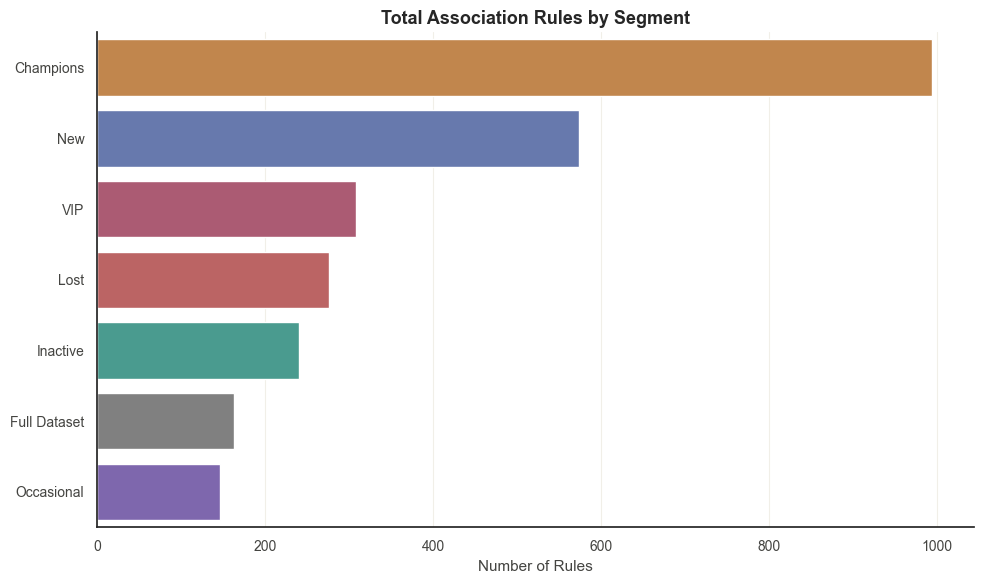

In [63]:
# Number of association rules by segment
segment_rule_counts = {
    'Occasional': len(rules_occ),
    'Champions': len(rules_champ),
    'VIP': len(rules_vip),
    'Inactive': len(rules_inac),
    'New': len(rules_new),
    'Lost': len(rules_lost),
    'Full Dataset': len(rules)
}

rule_counts_df = (
    pd.DataFrame(
        segment_rule_counts.items(),
        columns=['Segment', 'Rules']
    )
    .sort_values('Rules', ascending=False)
)

# Setting figures
fig, ax = plt.subplots(figsize=(10, 6))

# Barplot
sns.barplot(
    data=rule_counts_df,
    y='Segment',
    x='Rules',
    hue='Segment',
    palette=color_assign_mba,
    legend=False,
    ax=ax
)

# Format
ax.set_title('Total Association Rules by Segment')
ax.set_xlabel('Number of Rules')
ax.set_ylabel('')

plt.tight_layout()
plt.show()

Champions produces by far the most rules (~994), consistent with being the 
largest, most active segment — more transactions and more distinct products 
create more possible combinations. 

New Customers show a surprisingly high number of frequent itemsets (~573) despite having one of the smallest transaction volumes.     
This suggests that smaller transaction groups can contain recurring product combinations that contribute to the frequent itemsets and may influence the resulting association rules.

Occasional and full dataset — despite having the most transactions overall — produces the 
fewest rules, This suggests that transaction volume alone does not fully explain the number of rules; the variety and concentration of purchased products also appear to play a role.

#### **Lift distribution by segment**

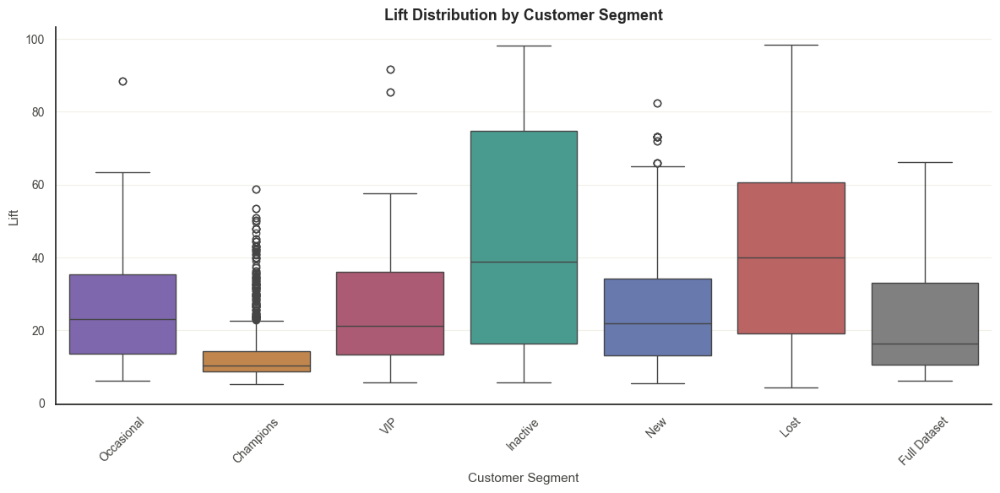

In [64]:
# Setting figures
fig, ax = plt.subplots(figsize=(12, 6))

# Boxplot
sns.boxplot(
    data=all_rules,
    x='Segment',
    y='lift',
    hue='Segment',
    palette=color_assign_mba,
    legend=False,
    ax=ax
)

# Format
ax.set_title('Lift Distribution by Customer Segment',)
ax.set_xlabel('Customer Segment')
ax.set_ylabel('Lift')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Champions has the lowest and tightest lift distribution, with many outliers 
above the box — high transaction volume dilutes individual product 
associations. 

Inactive and Lost, the smallest segments, show the highest 
median lift and the widest spread, although this pattern is not consistent across all small segments, as shown by New Customers.

Occasional, VIP, and New sit closer to the Full Dataset's distribution, 
suggesting these segments behave more like an "average" customer profile 
than the extremes (Champions vs Inactive/Lost).

#### **Support, Lift & Confidence by segment**

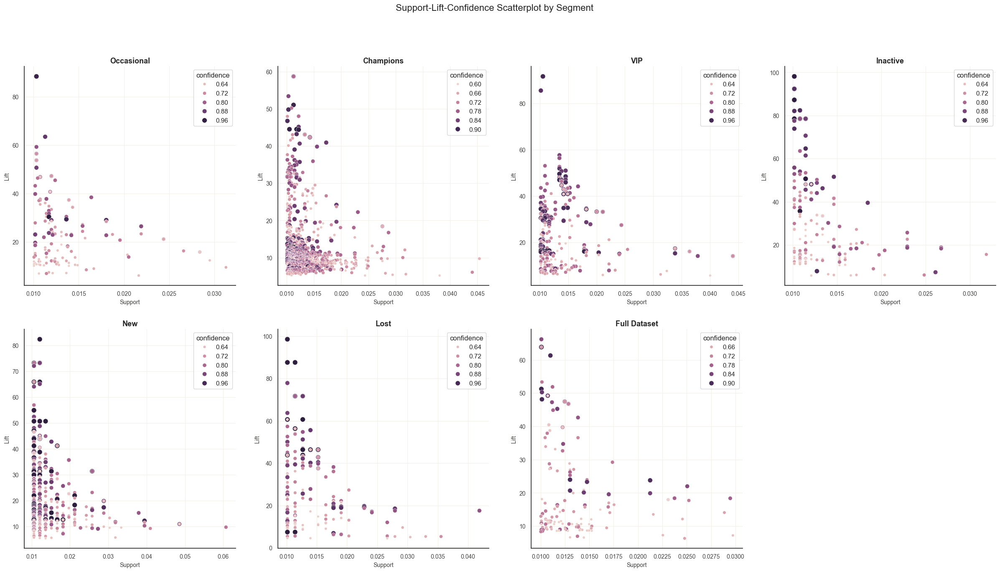

In [65]:
# Setting figures
fig, ((ax1, ax2, ax3, ax4), (ax5, ax6, ax7, ax8)) = plt.subplots(2, 4, figsize=(30, 15))

# Creating scatterplot by segment using support, confidence and lift
sns.scatterplot(data=rules_occ, x='support', y='lift', hue='confidence', size='confidence', ax=ax1)
sns.scatterplot(data=rules_champ, x='support', y='lift', hue='confidence', size='confidence', ax=ax2)
sns.scatterplot(data=rules_vip, x='support', y='lift', hue='confidence', size='confidence', ax=ax3)
sns.scatterplot(data=rules_inac, x='support', y='lift', hue='confidence', size='confidence', ax=ax4)
sns.scatterplot(data=rules_new, x='support', y='lift', hue='confidence', size='confidence', ax=ax5)
sns.scatterplot(data=rules_lost, x='support', y='lift', hue='confidence', size='confidence', ax=ax6)
sns.scatterplot(data=rules, x='support', y='lift', hue='confidence', size='confidence', ax=ax7)

# titles
ax1.set_title('Occasional')
ax2.set_title('Champions')
ax3.set_title('VIP')
ax4.set_title('Inactive')
ax5.set_title('New')
ax6.set_title('Lost')
ax7.set_title('Full Dataset')
ax8.set_visible(False)

# format
for ax in [ax1, ax2, ax3, ax4, ax5, ax6, ax7]:
    ax.set_xlabel('Support', fontsize=10)
    ax.set_ylabel('Lift', fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Support-Lift-Confidence Scatterplot by Segment',fontsize=16)
plt.show()

Each segment's scatter shows the same general shape — high lift concentrated 
at low support, gradually deacreasing as support increases — but Inactive, Lost, and 
New reach much higher lift values (up to ~100) than Champions, consistent with the boxplot above. 

Higher-lift rules often also show higher confidence, suggesting that some of the strongest associations are also consistently observed within their respective segments.

#### **Frequent products by segment (Support)**

In [66]:
# top 10 support single items
fi_10 = frequent_itemsets[frequent_itemsets['itemsets'].apply(len) == 1].sort_values('support', ascending=False).head(10)
fi_10_occ = frequent_itemsets_occ[frequent_itemsets_occ['itemsets'].apply(len) == 1].sort_values('support', ascending=False).head(10)
fi_10_champ = frequent_itemsets_champ[frequent_itemsets_champ['itemsets'].apply(len) == 1].sort_values('support', ascending=False).head(10)
fi_10_vip = frequent_itemsets_vip[frequent_itemsets_vip['itemsets'].apply(len) == 1].sort_values('support', ascending=False).head(10)
fi_10_inac = frequent_itemsets_inac[frequent_itemsets_inac['itemsets'].apply(len) == 1].sort_values('support', ascending=False).head(10)
fi_10_new = frequent_itemsets_new[frequent_itemsets_new['itemsets'].apply(len) == 1].sort_values('support', ascending=False).head(10)
fi_10_lost = frequent_itemsets_lost[frequent_itemsets_lost['itemsets'].apply(len) == 1].sort_values('support', ascending=False).head(10)

In [67]:
# Concatenating top 10 single frequent items by segment
all_fi_10 = pd.concat([
    fi_10_occ.assign(Segment='Occasional'),
    fi_10_champ.assign(Segment='Champions'),
    fi_10_vip.assign(Segment='VIP'),
    fi_10_inac.assign(Segment='Inactive'),
    fi_10_new.assign(Segment='New'),
    fi_10_lost.assign(Segment='Lost'),
    fi_10.assign(Segment='Full Dataset')
])

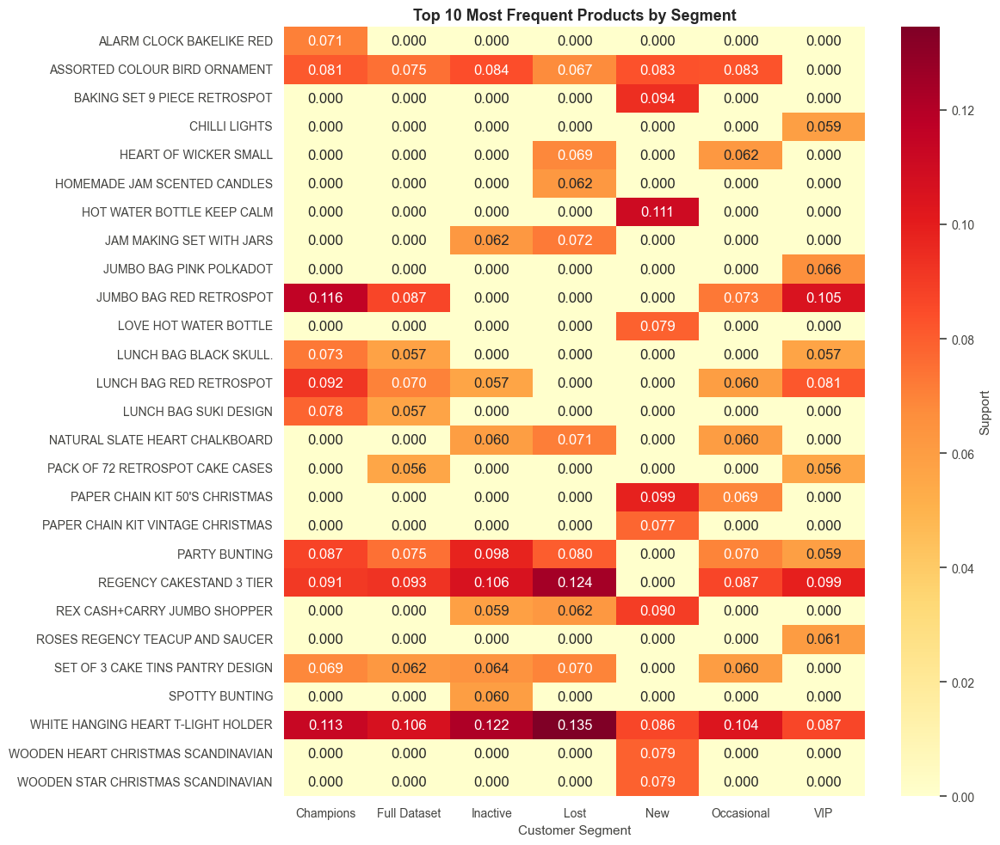

In [68]:
# Extracting product names from itemsets
all_fi_10['item'] = all_fi_10['itemsets'].apply(lambda x: list(x)[0])

# Creating pivot table for support by product and segment
heatmap_df = all_fi_10.pivot_table(
    index='item',
    columns='Segment',
    values='support',
    aggfunc='max'
).fillna(0)

# Setting figures
fig, ax = plt.subplots(figsize=(12, 10))

# Heatmap
sns.heatmap(
    heatmap_df,
    cmap='YlOrRd',
    annot=True,
    fmt='.3f',
    cbar_kws={'label': 'Support'},
    ax=ax
)

# Format
ax.set_title('Top 10 Most Frequent Products by Segment')
ax.set_xlabel('Customer Segment')
ax.set_ylabel('')

plt.tight_layout()
plt.show()

A few products — White Hanging Heart T-Light Holder, Jumbo Bag Red Retrospot, 
Regency Cakestand 3 Tier — appear across nearly every segment, representing 
genuinely universal bestsellers.     
But several products are exclusive to a single segment: Roses Regency Teacup and Saucer (Occasional only), Chilli 
Lights (VIP only), Baking Set 9 Piece Retrospot and Paper Chain Kit 50's 
Christmas (New only),    
Wooden Heart/Star Christmas Scandinavian (Lost only), 
Alarm Clock Bakelike Red (Champions only). 

This mirrors the association rule findings — individual product popularity, not just co-purchase patterns, 
also differs meaningfully by segment.

#### **Summary Findings**

Segmenting before running Market Basket Analysis reveals substantially more 
association rules and stronger, more distinct patterns than applying MBA to 
the full dataset alone. While the full dataset's top rules are dominated by     
a narrow set of products (Regency tableware, Poppy's Playhouse sets), the 
segmented approach surfaces entirely different top products and rules per 
segment — herb markers in Inactive/Lost, wooden decorations in VIP, party     
items in Champions — none of which appear in the full dataset's own top 
results. 

These results suggest that a segment-level MBA approach can uncover purchasing patterns that are less visible when analysing the full customer base in aggregate.

##